<a href="https://colab.research.google.com/github/MOHANCHARAN24/MlOps/blob/main/MLOPS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Problem Statement:
"""
There is no repeatable, quantifiable framework that maps curriculum-taught skills against industry-required skills (as evidenced by job postings, hiring test patterns, and recruiter feedback) to identify, rank, and prioritize employability skill gaps for CSE graduates.

Stated formally: Given a set of curriculum-covered skills (with coverage depth) and a set of industry-demanded skills (with demand intensity), design a decision framework that computes a per-skill gap score, classifies gaps by severity, and produces actionable, prioritized recommendations for curriculum designers and students."""

Background
Computer Science & Engineering programs in India, including autonomous universities like VFSTR, follow curricula that are revised periodically (typically every 3–4 years) through Boards of Studies. In contrast, the technology industry's skill demands shift continuously — new frameworks, cloud platforms, and now generative AI/LLM tooling become baseline expectations within a year or two of emerging. This creates a structural lag between what is taught and what is hired for.

Placement drives (Infosys SP/DSE, TCS NQT, Cognizant, Accenture, etc.) reveal this gap concretely: recruiters test DSA depth, system design intuition, and applied programming fluency that often exceeds what a standard syllabus covers explicitly, while simultaneously placing low weight on some topics the curriculum spends significant hours on. Most CSE departments currently have no systematic, data-driven way to see this misalignment — decisions about curriculum revision rely on faculty judgment, sporadic industry-advisory-board feedback, and anecdotal placement outcomes rather than a structured comparison of curriculum content against real hiring signals.

Motivation for this Project
Final-year students (including the author) experience this gap directly while preparing for placements — realizing late that certain heavily-tested areas (advanced DSA patterns, cloud fundamentals, GenAI/LLM familiarity) were only lightly touched in coursework, while significant academic time went to topics rarely tested.
Existing curriculum feedback mechanisms are qualitative and infrequent (annual/biannual Board of Studies reviews), whereas hiring requirements shift faster.
A structured framework benefits three stakeholders at once: departments (evidence for curriculum revision), students (a personalized gap report to guide self-study), and placement cells (a data backing for training/bootcamp design).
Personal relevance: having gone through Infosys SP/DSE and TCS NQT prep cycles, the author has first-hand pattern data on which skills the curriculum under-serves relative to what OA/interview rounds actually test.

Project Objectives
Build a taxonomy of employability-relevant skills spanning core CS, programming, tools/DevOps, AI/ML, data, and soft skills.
Design a scoring model that quantifies (a) curriculum coverage/depth per skill and (b) industry demand per skill, derived from job postings, OA/interview pattern analysis, and recruiter-published criteria.
Compute a Gap Score per skill and classify gaps into High/Medium/Low priority tiers.
Build a decision framework/dashboard that ranks skills by gap severity and links each to actionable interventions (e.g., add elective, revise lab component, recommend certification).
Validate the framework against real placement outcomes (e.g., correlate individual students' self-assessed proficiency with their placement success rate) to test predictive value.
Produce a reusable tool (spreadsheet/dashboard or lightweight web app) that a department can re-run each admission cycle with updated data.\\

Project Scope
In scope:

CSE (and closely related specializations — AI/ML, Data Science tracks) undergraduate curriculum, focused on final two years where employability skills concentrate.
Skill data sourced from: university syllabus documents, sample job postings/JDs from target recruiters (IT services + product companies), and OA/interview pattern data from placement prep resources.
A quantitative gap-scoring model, a prioritized skill-gap report, and a set of curriculum-revision recommendations.
Out of scope:

Actual curriculum revision/approval (framework informs, doesn't execute, Board of Studies decisions).
Real-time/continuously updating job market scraping (data refresh is treated as periodic, not live).
Non-CSE branches, postgraduate programs, and soft-skill training program design in depth (soft skills are scored but not the framework's primary focus).

In [ ]:
###proProposed Methodology
"""Skill Taxonomy Construction — Compile a master skill list (~35–45 skills) across categories (Core CS, Programming, Tools, Web/Backend, Cloud/DevOps, AI/ML, Data, Security, Aptitude, Soft Skills) via literature review, syllabus analysis, and JD text analysis.
Curriculum Mapping — For each skill, mark whether/how deeply it is covered in the CSE syllabus (course-by-course mapping, Bloom's-taxonomy-informed depth rating 1–5).
Industry Demand Extraction — Collect a sample of job postings/OA patterns per target company (Infosys, TCS, Cognizant, product firms) and score each skill's demand intensity (frequency-weighted, 1–10 scale), optionally using simple NLP keyword extraction on JD text.
Student Proficiency Data Collection — Gather self-assessed or test-based proficiency scores per skill from a student sample (survey instrument, 1–5 scale).
Gap Score Computation — Define Gap Score = Industry Demand − (Curriculum Depth and/or Avg. Student Proficiency, scaled comparably); classify into High/Medium/Low tiers via threshold rules.
Decision Framework Design — Build a rule-based or weighted decision matrix that converts gap tiers into recommended actions (new elective, lab hours increase, industry certification tie-up, workshop).
Validation — Cross-check gap rankings against actual placement outcome data (offer rate, package, rounds cleared) to see if high-gap skills correlate with placement friction.
Tool Packaging — Implement as a spreadsheet model with live formulas (or a small web dashboard) so the department can re-run it with new data each year."""

## 1. SKILL TAXONOMY

In [ ]:
import pandas as pd

# Define skill categories and corresponding skills
skill_data = {
    'Core CS': [
        'Data Structures & Algorithms (DSA)', 'Operating Systems (OS)', 'Computer Networks (CN)',
        'Database Management Systems (DBMS)', 'Object-Oriented Programming (OOP)', 'Software Engineering (SE)',
        'Theory of Computation (TOC)', 'Compiler Design', 'Computer Architecture'
    ],
    'Programming': [
        'Python', 'Java', 'C++', 'JavaScript', 'SQL', 'Bash/Shell Scripting', 'Version Control (Git)'
    ],
    'Tools/DevOps': [
        'Docker', 'Kubernetes', 'CI/CD (Jenkins/GitLab CI)', 'Cloud Platforms (AWS/Azure/GCP)',
        'RESTful APIs', 'Linux Fundamentals', 'Agile/Scrum'
    ],
    'Web/Backend': [
        'HTML/CSS/JavaScript', 'Frontend Frameworks (React/Angular/Vue)', 'Backend Frameworks (Django/Spring/Node.js)',
        'Microservices', 'API Design'
    ],
    'Cloud': [
        'Cloud Computing Concepts', 'AWS Services', 'Azure Services', 'GCP Services', 'Serverless Architectures'
    ],
    'AI/ML': [
        'Machine Learning Fundamentals', 'Deep Learning', 'Natural Language Processing (NLP)',
        'Computer Vision', 'Generative AI/LLMs', 'ML Frameworks (TensorFlow/PyTorch)'
    ],
    'Data': [
        'Data Analysis', 'Data Visualization', 'Big Data Technologies (Spark/Hadoop)', 'Data Warehousing',
        'SQL (Advanced)'
    ],
    'Security': [
        'Cybersecurity Fundamentals', 'Network Security', 'Web Security', 'Cryptography'
    ],
    'Aptitude': [
        'Quantitative Aptitude', 'Logical Reasoning', 'Verbal Ability'
    ],
    'Soft Skills': [
        'Communication', 'Teamwork', 'Problem-Solving', 'Adaptability', 'Time Management', 'Critical Thinking'
    ]
}

# Create a list of dictionaries for easier DataFrame creation
skills_list = []
for category, skills in skill_data.items():
    for skill in skills:
        skills_list.append({'Category': category, 'Skill': skill})

# Create the DataFrame
df_skills = pd.DataFrame(skills_list)

print(f"Total skills in taxonomy: {len(df_skills)}")
display(df_skills.head())
display(df_skills.tail())


Total skills in taxonomy: 57


,Category,Skill
0,Core CS,Data Structures & Algorithms (DSA)
1,Core CS,Operating Systems (OS)
2,Core CS,Computer Networks (CN)
3,Core CS,Database Management Systems (DBMS)
4,Core CS,Object-Oriented Programming (OOP)


,Category,Skill
52,Soft Skills,Teamwork
53,Soft Skills,Problem-Solving
54,Soft Skills,Adaptability
55,Soft Skills,Time Management
56,Soft Skills,Critical Thinking


## 2. CURRICULUM MAPPING

In [ ]:
# Initialize Curriculum_Covered and Curriculum_Depth columns
df_skills['Curriculum_Covered'] = 'N'
df_skills['Curriculum_Depth'] = 0

# Define typical Indian CSE syllabus coverage and depth (1-5, Bloom's Taxonomy informed)
# 1: Awareness, 2: Basic Understanding, 3: Application, 4: Analysis/Design, 5: Synthesis/Evaluation

# Core CS Skills (generally well covered)
curriculum_coverage = {
    'Data Structures & Algorithms (DSA)': {'Covered': 'Y', 'Depth': 4},
    'Operating Systems (OS)': {'Covered': 'Y', 'Depth': 3},
    'Computer Networks (CN)': {'Covered': 'Y', 'Depth': 3},
    'Database Management Systems (DBMS)': {'Covered': 'Y', 'Depth': 3},
    'Object-Oriented Programming (OOP)': {'Covered': 'Y', 'Depth': 4},
    'Software Engineering (SE)': {'Covered': 'Y', 'Depth': 3},
    'Theory of Computation (TOC)': {'Covered': 'Y', 'Depth': 2},
    'Compiler Design': {'Covered': 'Y', 'Depth': 2},
    'Computer Architecture': {'Covered': 'Y', 'Depth': 3},

    # Programming Skills (Varying coverage, Python/Java often well covered)
    'Python': {'Covered': 'Y', 'Depth': 3},
    'Java': {'Covered': 'Y', 'Depth': 3},
    'C++': {'Covered': 'Y', 'Depth': 3},
    'JavaScript': {'Covered': 'N', 'Depth': 1}, # Often basic/optional
    'SQL': {'Covered': 'Y', 'Depth': 3},
    'Bash/Shell Scripting': {'Covered': 'N', 'Depth': 1}, # Often only basic command line
    'Version Control (Git)': {'Covered': 'N', 'Depth': 2}, # Often self-taught or in projects, not formal course

    # Tools/DevOps (Often NOT formally taught, or very shallow)
    'Docker': {'Covered': 'N', 'Depth': 1},
    'Kubernetes': {'Covered': 'N', 'Depth': 1},
    'CI/CD (Jenkins/GitLab CI)': {'Covered': 'N', 'Depth': 1},
    'Cloud Platforms (AWS/Azure/GCP)': {'Covered': 'N', 'Depth': 1},
    'RESTful APIs': {'Covered': 'N', 'Depth': 2}, # May be touched upon in web dev, but not deep design
    'Linux Fundamentals': {'Covered': 'Y', 'Depth': 2},
    'Agile/Scrum': {'Covered': 'N', 'Depth': 1},

    # Web/Backend (Often basic coverage)
    'HTML/CSS/JavaScript': {'Covered': 'Y', 'Depth': 2},
    'Frontend Frameworks (React/Angular/Vue)': {'Covered': 'N', 'Depth': 1},
    'Backend Frameworks (Django/Spring/Node.js)': {'Covered': 'N', 'Depth': 2},
    'Microservices': {'Covered': 'N', 'Depth': 1},
    'API Design': {'Covered': 'N', 'Depth': 1},

    # Cloud (Minimal to no formal coverage)
    'Cloud Computing Concepts': {'Covered': 'N', 'Depth': 2},
    'AWS Services': {'Covered': 'N', 'Depth': 1},
    'Azure Services': {'Covered': 'N', 'Depth': 1},
    'GCP Services': {'Covered': 'N', 'Depth': 1},
    'Serverless Architectures': {'Covered': 'N', 'Depth': 1},

    # AI/ML (Often basic, GenAI is new)
    'Machine Learning Fundamentals': {'Covered': 'Y', 'Depth': 3},
    'Deep Learning': {'Covered': 'N', 'Depth': 2},
    'Natural Language Processing (NLP)': {'Covered': 'N', 'Depth': 2},
    'Computer Vision': {'Covered': 'N', 'Depth': 2},
    'Generative AI/LLMs': {'Covered': 'N', 'Depth': 1},
    'ML Frameworks (TensorFlow/PyTorch)': {'Covered': 'N', 'Depth': 1},

    # Data (Varying coverage)
    'Data Analysis': {'Covered': 'Y', 'Depth': 2},
    'Data Visualization': {'Covered': 'N', 'Depth': 1},
    'Big Data Technologies (Spark/Hadoop)': {'Covered': 'N', 'Depth': 1},
    'Data Warehousing': {'Covered': 'N', 'Depth': 1},
    'SQL (Advanced)': {'Covered': 'N', 'Depth': 2},

    # Security (Fundamentals usually covered)
    'Cybersecurity Fundamentals': {'Covered': 'Y', 'Depth': 2},
    'Network Security': {'Covered': 'Y', 'Depth': 2},
    'Web Security': {'Covered': 'N', 'Depth': 1},
    'Cryptography': {'Covered': 'Y', 'Depth': 3},

    # Aptitude (Often covered by dedicated prep, not CSE courses)
    'Quantitative Aptitude': {'Covered': 'Y', 'Depth': 3},
    'Logical Reasoning': {'Covered': 'Y', 'Depth': 3},
    'Verbal Ability': {'Covered': 'Y', 'Depth': 3},

    # Soft Skills (Often via workshops, not graded courses)
    'Communication': {'Covered': 'Y', 'Depth': 2},
    'Teamwork': {'Covered': 'Y', 'Depth': 2},
    'Problem-Solving': {'Covered': 'Y', 'Depth': 3},
    'Adaptability': {'Covered': 'Y', 'Depth': 2},
    'Time Management': {'Covered': 'Y', 'Depth': 2},
    'Critical Thinking': {'Covered': 'Y', 'Depth': 3}
}

# Update DataFrame with curriculum mapping
for index, row in df_skills.iterrows():
    skill_name = row['Skill']
    if skill_name in curriculum_coverage:
        df_skills.loc[index, 'Curriculum_Covered'] = curriculum_coverage[skill_name]['Covered']
        df_skills.loc[index, 'Curriculum_Depth'] = curriculum_coverage[skill_name]['Depth']
    # Modern skills explicitly flagged as NOT formally taught or with low depth
    # This is handled by setting 'N' and low depth for many in the dict above

print("Curriculum mapping added to df_skills:")
display(df_skills.head())
display(df_skills.tail())
display(df_skills[df_skills['Curriculum_Covered'] == 'N'].head()) # Show some skills NOT formally covered


Curriculum mapping added to df_skills:


,Category,Skill,Curriculum_Covered,Curriculum_Depth
0,Core CS,Data Structures & Algorithms (DSA),Y,4
1,Core CS,Operating Systems (OS),Y,3
2,Core CS,Computer Networks (CN),Y,3
3,Core CS,Database Management Systems (DBMS),Y,3
4,Core CS,Object-Oriented Programming (OOP),Y,4


,Category,Skill,Curriculum_Covered,Curriculum_Depth
52,Soft Skills,Teamwork,Y,2
53,Soft Skills,Problem-Solving,Y,3
54,Soft Skills,Adaptability,Y,2
55,Soft Skills,Time Management,Y,2
56,Soft Skills,Critical Thinking,Y,3


,Category,Skill,Curriculum_Covered,Curriculum_Depth
12,Programming,JavaScript,N,1
14,Programming,Bash/Shell Scripting,N,1
15,Programming,Version Control (Git),N,2
16,Tools/DevOps,Docker,N,1
17,Tools/DevOps,Kubernetes,N,1


## 3. INDUSTRY DEMAND SCORING

In [ ]:
# Initialize Industry_Demand_Score column
df_skills['Industry_Demand_Score'] = 0

# Define industry demand scores (1-10) based on Infosys SP/DSE, TCS NQT, product company hiring patterns
# Justification provided in comments for selected skills.
industry_demand = {
    'Data Structures & Algorithms (DSA)': 10, # Crucial for all tech interviews, especially for SP/DSE & product roles.
    'Operating Systems (OS)': 7, # Important for foundational understanding, asked in some interviews.
    'Computer Networks (CN)': 7, # Important for foundational understanding, asked in some interviews.
    'Database Management Systems (DBMS)': 8, # SQL is essential, concepts for system design.
    'Object-Oriented Programming (OOP)': 8, # Core programming paradigm, tested heavily.
    'Software Engineering (SE)': 6, # Concepts are useful, direct testing is less common than application.
    'Theory of Computation (TOC)': 3, # Rarely directly tested, academic relevance.
    'Compiler Design': 2, # Highly specialized, almost never tested in general interviews.
    'Computer Architecture': 5, # Foundational, but less direct testing than OS/CN.

    'Python': 9, # High demand for scripting, data science, and backend roles.
    'Java': 8, # Perennial enterprise favorite, strong demand.
    'C++': 7, # Strong for performance-critical roles, competitive programming.
    'JavaScript': 7, # Essential for web development.
    'SQL': 9, # Universal database language, critical for almost all roles.
    'Bash/Shell Scripting': 5, # Useful for DevOps/automation, less for general roles.
    'Version Control (Git)': 8, # Absolutely essential for collaborative development.

    'Docker': 7, # Growing demand for containerization in DevOps.
    'Kubernetes': 6, # High demand for cloud-native/DevOps roles, but often more senior.
    'CI/CD (Jenkins/GitLab CI)': 7, # Key for modern software delivery pipelines.
    'Cloud Platforms (AWS/Azure/GCP)': 9, # Very high demand across all levels for cloud awareness.
    'RESTful APIs': 8, # Essential for any modern application development.
    'Linux Fundamentals': 7, # Core skill for server-side development and DevOps.
    'Agile/Scrum': 6, # Project management methodology, expected awareness.

    'HTML/CSS/JavaScript': 7, # Frontend basics, good demand for web roles.
    'Frontend Frameworks (React/Angular/Vue)': 7, # Specific framework knowledge boosts employability.
    'Backend Frameworks (Django/Spring/Node.js)': 8, # Strong demand for specific backend expertise.
    'Microservices': 7, # Architectural pattern, increasing demand for scalable systems.
    'API Design': 7, # Critical for building robust and usable services.

    'Cloud Computing Concepts': 8, # Foundational understanding is highly valued.
    'AWS Services': 9, # Specific cloud platform knowledge is in very high demand.
    'Azure Services': 8, # Strong demand, especially in enterprise environments.
    'GCP Services': 7, # Growing demand, good for broader cloud skill set.
    'Serverless Architectures': 6, # Niche but growing, often tied to specific cloud platforms.

    'Machine Learning Fundamentals': 7, # Increasing demand across various roles.
    'Deep Learning': 6, # Specialized, but high demand in AI/ML specific roles.
    'Natural Language Processing (NLP)': 6, # Specialized, high demand in specific AI/ML fields.
    'Computer Vision': 6, # Specialized, high demand in specific AI/ML fields.
    'Generative AI/LLMs': 8, # Very high and rapidly increasing demand, cutting-edge.
    'ML Frameworks (TensorFlow/PyTorch)': 7, # Practical application of ML, high demand.

    'Data Analysis': 7, # Essential for many roles, not just pure data science.
    'Data Visualization': 6, # Important for presenting insights.
    'Big Data Technologies (Spark/Hadoop)': 6, # Demand for handling large datasets.
    'Data Warehousing': 5, # More specialized, but important for enterprise data.
    'SQL (Advanced)': 8, # Deep SQL skills are highly valued.

    'Cybersecurity Fundamentals': 6, # General awareness is good.
    'Network Security': 5, # Specialized.
    'Web Security': 7, # Critical for web development roles.
    'Cryptography': 5, # Foundational, but specialized application.

    'Quantitative Aptitude': 9, # Essential for all entrance/pre-interview tests.
    'Logical Reasoning': 9, # Essential for all entrance/pre-interview tests.
    'Verbal Ability': 8, # Essential for communication and initial screening.

    'Communication': 9, # Universally critical for teamwork and client interaction.
    'Teamwork': 8, # Essential for project execution in any company.
    'Problem-Solving': 10, # The most crucial skill, tested in every technical interview.
    'Adaptability': 8, # Important in fast-changing tech landscape.
    'Time Management': 7, # Important for productivity and project deadlines.
    'Critical Thinking': 9 # Key for independent work and complex problem solving.
}

# Update DataFrame with industry demand scores
for index, row in df_skills.iterrows():
    skill_name = row['Skill']
    if skill_name in industry_demand:
        df_skills.loc[index, 'Industry_Demand_Score'] = industry_demand[skill_name]

print("Industry demand scores added to df_skills:")
display(df_skills.head())
display(df_skills.tail())


Industry demand scores added to df_skills:


,Category,Skill,Curriculum_Covered,Curriculum_Depth,Industry_Demand_Score
0,Core CS,Data Structures & Algorithms (DSA),Y,4,10
1,Core CS,Operating Systems (OS),Y,3,7
2,Core CS,Computer Networks (CN),Y,3,7
3,Core CS,Database Management Systems (DBMS),Y,3,8
4,Core CS,Object-Oriented Programming (OOP),Y,4,8


,Category,Skill,Curriculum_Covered,Curriculum_Depth,Industry_Demand_Score
52,Soft Skills,Teamwork,Y,2,8
53,Soft Skills,Problem-Solving,Y,3,10
54,Soft Skills,Adaptability,Y,2,8
55,Soft Skills,Time Management,Y,2,7
56,Soft Skills,Critical Thinking,Y,3,9


## 4. SYNTHETIC STUDENT DATA

In [ ]:
import numpy as np

# Number of synthetic students
num_students = 180 # Between 150-200 as requested

# Initialize student DataFrame
df_students = pd.DataFrame({
    'StudentID': range(1, num_students + 1),
    'CGPA': np.random.uniform(6.0, 9.8, num_students).round(2) # CGPA between 6.0 and 9.8
})

# Assign specializations (e.g., General, AI/ML, Data Science, Cyber Security, Cloud Computing)
specializations = ['General CSE', 'AI/ML Specialization', 'Data Science Specialization', 'Cyber Security Specialization', 'Cloud Computing Specialization']
df_students['Specialization'] = np.random.choice(specializations, num_students)

# Generate per-skill self-assessed proficiency (1-5)
# Correlation logic:
# 1. Higher CGPA generally means higher proficiency.
# 2. Skills covered in the curriculum tend to have higher base proficiency.
# 3. Specialization can boost proficiency in relevant skills.
# 4. Add random noise to make it realistic.

np.random.seed(42) # for reproducibility

for skill_idx, skill_row in df_skills.iterrows():
    skill_name = skill_row['Skill']
    curriculum_depth = skill_row['Curriculum_Depth']
    skill_category = skill_row['Category']

    proficiency_scores = []
    for student_idx, student_row in df_students.iterrows():
        cgpa = student_row['CGPA']
        specialization = student_row['Specialization']

        # Base proficiency influenced by curriculum depth and CGPA
        base_proficiency = (curriculum_depth / 5) * 2 + (cgpa / 10) * 3 # Scale curriculum depth to have some impact, CGPA to have more

        # Add specialization bonus for relevant skills
        if 'AI/ML' in specialization and skill_category == 'AI/ML':
            base_proficiency += 0.8
        elif 'Data Science' in specialization and skill_category == 'Data':
            base_proficiency += 0.8
        elif 'Cyber Security' in specialization and skill_category == 'Security':
            base_proficiency += 0.8
        elif 'Cloud Computing' in specialization and skill_category == 'Cloud':
            base_proficiency += 0.8
        elif 'Web/Backend' in skill_category and specialization == 'General CSE': # General CSE students might pick up Web/Backend more
            base_proficiency += 0.3
        elif 'Programming' in skill_category and specialization == 'General CSE':
            base_proficiency += 0.2

        # Add random noise (e.g., a student might be naturally good or bad at a skill)
        noise = np.random.uniform(-1.5, 1.5)
        proficiency = base_proficiency + noise

        # Ensure proficiency is within 1-5 range
        proficiency = max(1, min(5, proficiency))
        proficiency_scores.append(round(proficiency))

    df_students[f'Proficiency_{skill_name}'] = proficiency_scores

print(f"Generated synthetic data for {len(df_students)} students.")
display(df_students.head())
display(df_students.describe())


Generated synthetic data for 180 students.


,StudentID,CGPA,Specialization,Proficiency_Data Structures & Algorithms (DSA),Proficiency_Operating Systems (OS),Proficiency_Computer Networks (CN),Proficiency_Database Management Systems (DBMS),Proficiency_Object-Oriented Programming (OOP),Proficiency_Software Engineering (SE),Proficiency_Theory of Computation (TOC),...,Proficiency_Cryptography,Proficiency_Quantitative Aptitude,Proficiency_Logical Reasoning,Proficiency_Verbal Ability,Proficiency_Communication,Proficiency_Teamwork,Proficiency_Problem-Solving,Proficiency_Adaptability,Proficiency_Time Management,Proficiency_Critical Thinking
0,1,6.90,Cyber Security Specialization,3,3,3,5,5,2,4,...,5,4,2,5,3,3,2,4,1,4
1,2,7.10,Cyber Security Specialization,5,2,4,4,3,2,2,...,5,3,5,3,3,4,3,3,3,4
2,3,6.38,Cyber Security Specialization,4,4,3,2,2,2,2,...,3,2,2,4,2,2,3,3,2,4
3,4,6.74,General CSE,4,4,3,4,4,3,4,...,4,3,2,3,3,2,3,4,3,3
4,5,9.17,AI/ML Specialization,3,3,5,4,5,4,5,...,5,4,5,4,4,3,3,2,5,3


,StudentID,CGPA,Proficiency_Data Structures & Algorithms (DSA),Proficiency_Operating Systems (OS),Proficiency_Computer Networks (CN),Proficiency_Database Management Systems (DBMS),Proficiency_Object-Oriented Programming (OOP),Proficiency_Software Engineering (SE),Proficiency_Theory of Computation (TOC),Proficiency_Compiler Design,...,Proficiency_Cryptography,Proficiency_Quantitative Aptitude,Proficiency_Logical Reasoning,Proficiency_Verbal Ability,Proficiency_Communication,Proficiency_Teamwork,Proficiency_Problem-Solving,Proficiency_Adaptability,Proficiency_Time Management,Proficiency_Critical Thinking
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,...,180.000000,180.000000,180.00000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,90.500000,7.941778,3.833333,3.594444,3.683333,3.455556,3.894444,3.611111,3.277778,3.111111,...,3.744444,3.411111,3.60000,3.594444,3.244444,3.177778,3.433333,3.266667,3.138889,3.494444
std,52.105662,1.105667,0.912361,0.978525,1.054254,0.923451,0.918447,0.953611,1.008653,1.024225,...,0.986627,0.883043,0.93713,0.949550,0.966606,0.963905,0.909908,0.994959,1.045148,0.942463
min,1.000000,6.010000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,...,2.000000,2.000000,2.00000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000
25%,45.750000,7.010000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,2.000000,...,3.000000,3.000000,3.00000,3.000000,2.000000,2.000000,3.000000,2.750000,2.000000,3.000000
50%,90.500000,8.025000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,3.000000,4.00000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,135.250000,8.925000,5.000000,4.000000,5.000000,4.000000,5.000000,4.000000,4.000000,4.000000,...,5.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,180.000000,9.790000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## 5. GAP SCORE MODEL

In [ ]:
# Calculate average student proficiency for each skill
# Extract skill proficiency columns from df_students
proficiency_cols = [col for col in df_students.columns if col.startswith('Proficiency_')]

# Proceed only if proficiency columns are found
if proficiency_cols:
    avg_proficiency_per_skill = df_students[proficiency_cols].mean().reset_index()
    avg_proficiency_per_skill.columns = ['Skill_Col', 'Avg_Student_Proficiency']

    # Clean up skill names (remove 'Proficiency_' prefix)
    avg_proficiency_per_skill['Skill'] = avg_proficiency_per_skill['Skill_Col'].apply(lambda x: x.replace('Proficiency_', ''))
    avg_proficiency_per_skill = avg_proficiency_per_skill[['Skill', 'Avg_Student_Proficiency']]

    # Ensure 'Skill' columns are clean string types before merging
    df_skills['Skill'] = df_skills['Skill'].astype(str).str.strip()
    avg_proficiency_per_skill['Skill'] = avg_proficiency_per_skill['Skill'].astype(str).str.strip()

    # Drop any existing Avg_Student_Proficiency related columns from df_skills to prevent _x, _y suffixes on re-run
    df_skills = df_skills.drop(columns=[col for col in df_skills.columns if 'Avg_Student_Proficiency' in col], errors='ignore')

    # Merge average proficiency back into df_skills
    df_skills = pd.merge(df_skills, avg_proficiency_per_skill, on='Skill', how='left')
    # Fill any NaNs that might occur if a skill in df_skills had no matching proficiency data
    # Default to a mean or mid-range value (e.g., 3.0) if avg_proficiency_per_skill was empty (unlikely with current setup)
    df_skills['Avg_Student_Proficiency'] = df_skills['Avg_Student_Proficiency'].fillna(df_skills['Avg_Student_Proficiency'].mean() if not avg_proficiency_per_skill.empty else 3.0)
else:
    # If no proficiency columns found, initialize Avg_Student_Proficiency to a default value (e.g., 3.0)
    # This scenario should not happen with current data generation, but is a robust fallback.
    df_skills['Avg_Student_Proficiency'] = 3.0
    print("Warning: No 'Proficiency_' columns found in df_students. Initializing 'Avg_Student_Proficiency' to 3.0.")

# Scale Avg_Student_Proficiency from 1-5 to 1-10 range
# (Original_Value - Min_Original) * (Max_Scaled - Min_Scaled) / (Max_Original - Min_Original) + Min_Scaled
# (Avg_Student_Proficiency - 1) * (10 - 1) / (5 - 1) + 1
df_skills['Avg_Student_Proficiency_Scaled'] = ((df_skills['Avg_Student_Proficiency'] - 1) * 9 / 4) + 1

# Compute Gap Score = Industry_Demand_Score - Avg_Student_Proficiency_Scaled
df_skills['Gap_Score'] = df_skills['Industry_Demand_Score'] - df_skills['Avg_Student_Proficiency_Scaled']

# Classify gaps by severity (High/Medium/Low)
# Define thresholds for severity
# For example: High > 4, Medium > 2 and <= 4, Low <= 2
def classify_gap_severity(gap_score):
    if gap_score > 4:
        return 'High'
    elif gap_score > 2:
        return 'Medium'
    else:
        return 'Low'

df_skills['Gap_Severity'] = df_skills['Gap_Score'].apply(classify_gap_severity)

# Rank and print the Top 10 highest-gap skills
# df_skills_ranked = df_skills.sort_values(by='Gap_Score', ascending=False) # Moved this to the next cell

print("Gap Score Model results added to df_skills:")
display(df_skills.head())
display(df_skills.tail())

# print("\nTop 10 Highest-Gap Skills:")
# display(df_skills_ranked[['Skill', 'Category', 'Industry_Demand_Score', 'Curriculum_Depth', 'Avg_Student_Proficiency', 'Avg_Student_Proficiency_Scaled', 'Gap_Score', 'Gap_Severity']].head(10)) # Moved this to the next cell

Gap Score Model results added to df_skills:


,Category,Skill,Curriculum_Covered,Curriculum_Depth,Industry_Demand_Score,Gap_Score,Gap_Severity,Recommendation,Avg_Student_Proficiency,Avg_Student_Proficiency_Scaled
0,Core CS,Data Structures & Algorithms (DSA),Y,4,10,2.6250,Medium,**Curriculum Enhancement:** Review and update ...,3.833333,7.3750
1,Core CS,Operating Systems (OS),Y,3,7,0.1625,Low,**No Immediate Action Needed:** Gap for 'Opera...,3.594444,6.8375
2,Core CS,Computer Networks (CN),Y,3,7,-0.0375,Low,**No Immediate Action Needed:** Gap for 'Compu...,3.683333,7.0375
3,Core CS,Database Management Systems (DBMS),Y,3,8,1.4750,Low,**Maintain & Monitor:** Continue current cover...,3.455556,6.5250
4,Core CS,Object-Oriented Programming (OOP),Y,4,8,0.4875,Low,**Maintain & Monitor:** Continue current cover...,3.894444,7.5125


,Category,Skill,Curriculum_Covered,Curriculum_Depth,Industry_Demand_Score,Gap_Score,Gap_Severity,Recommendation,Avg_Student_Proficiency,Avg_Student_Proficiency_Scaled
52,Soft Skills,Teamwork,Y,2,8,2.1000,Medium,**Optional Skill Development:** Provide resour...,3.177778,5.9000
53,Soft Skills,Problem-Solving,Y,3,10,3.5250,Medium,**Optional Skill Development:** Provide resour...,3.433333,6.4750
54,Soft Skills,Adaptability,Y,2,8,1.9000,Low,**No Immediate Action Needed:** Gap for 'Adapt...,3.266667,6.1000
55,Soft Skills,Time Management,Y,2,7,1.1875,Low,**No Immediate Action Needed:** Gap for 'Time ...,3.138889,5.8125
56,Soft Skills,Critical Thinking,Y,3,9,2.3875,Medium,**Optional Skill Development:** Provide resour...,3.494444,6.6125


## 6. VISUALIZATIONS

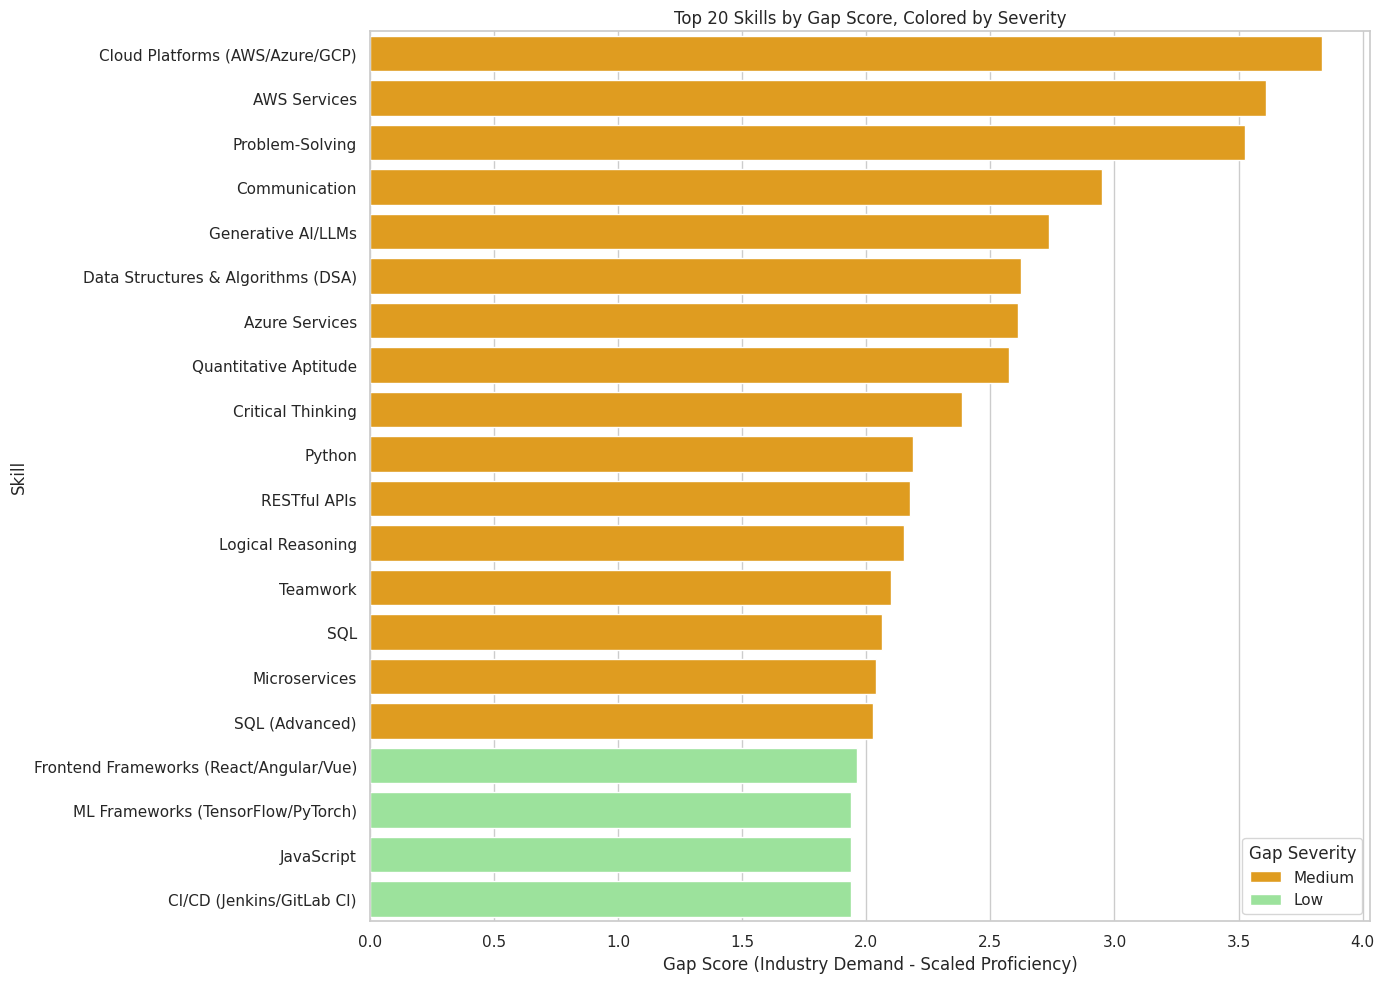

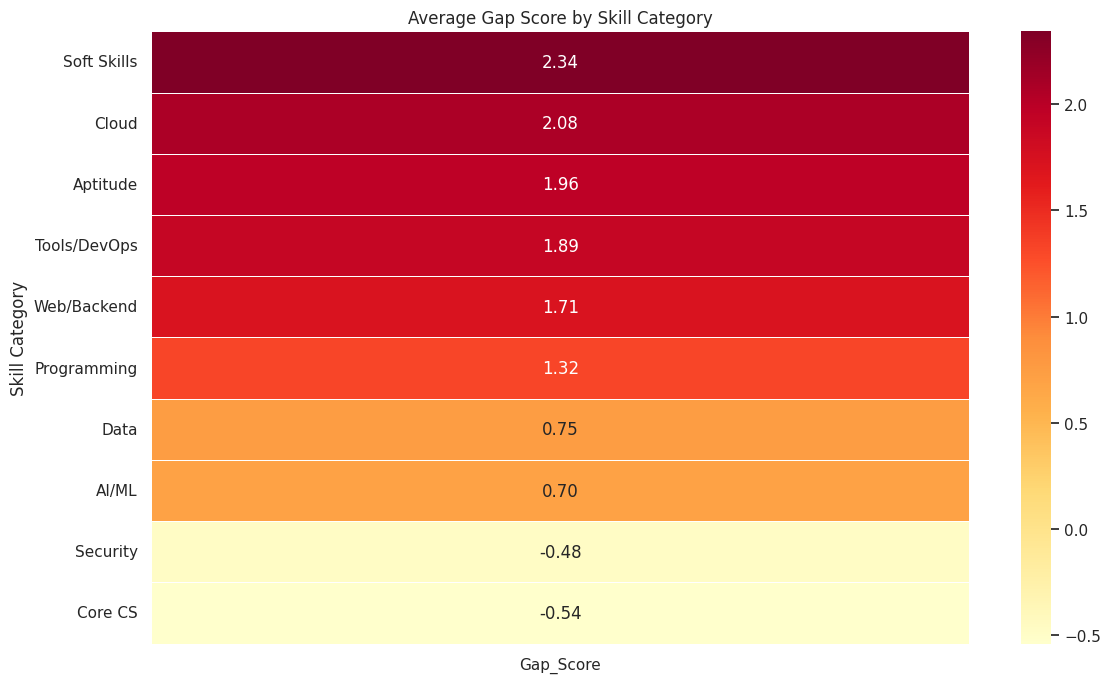

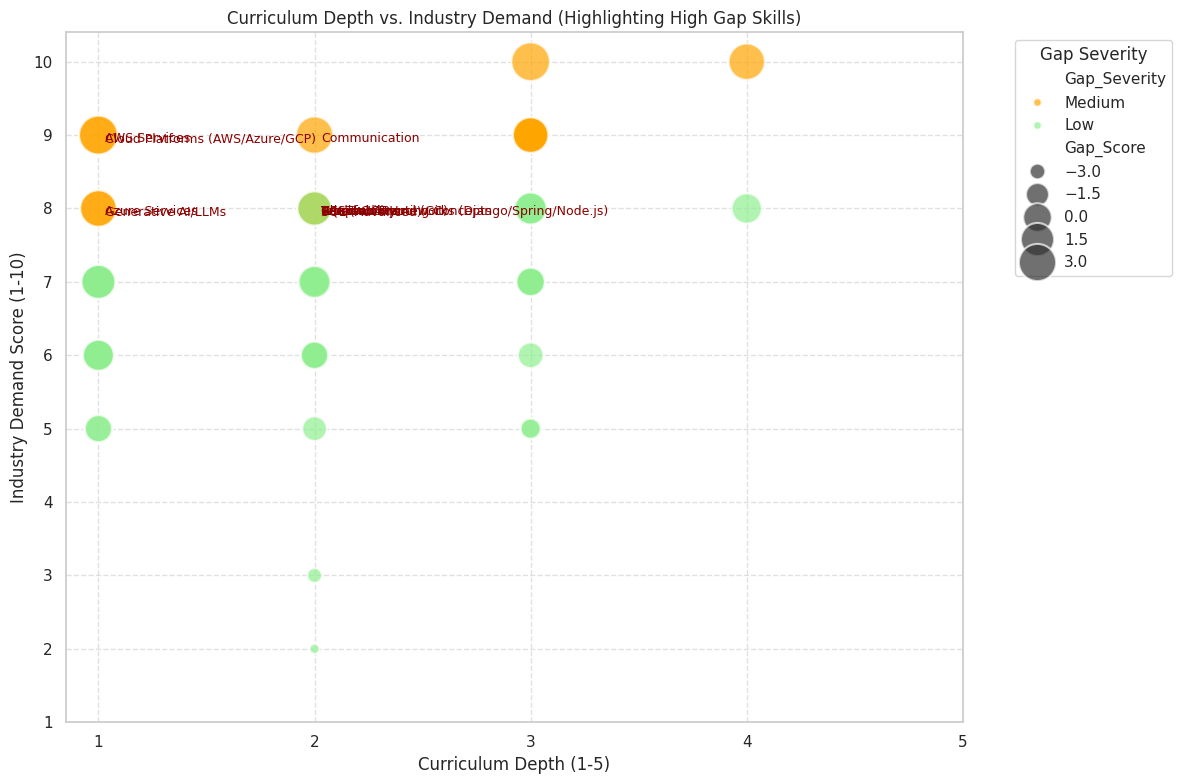

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- (a) Bar chart of gap score by skill, colored by severity tier ---
plt.figure(figsize=(14, 10))
sns.barplot(x='Gap_Score', y='Skill', hue='Gap_Severity', data=df_skills_ranked.head(20), dodge=False, palette={'High': 'red', 'Medium': 'orange', 'Low': 'lightgreen'})
plt.title('Top 20 Skills by Gap Score, Colored by Severity')
plt.xlabel('Gap Score (Industry Demand - Scaled Proficiency)')
plt.ylabel('Skill')
plt.legend(title='Gap Severity')
plt.tight_layout()
plt.show()

# --- (b) Heatmap of skill category vs. average gap score ---
avg_gap_by_category = df_skills.groupby('Category')['Gap_Score'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 7))
sns.heatmap(avg_gap_by_category.set_index('Category'), annot=True, cmap='YlOrRd', fmt=".2f", linewidths=.5)
plt.title('Average Gap Score by Skill Category')
plt.xlabel('')
plt.ylabel('Skill Category')
plt.tight_layout()
plt.show()

# --- (c) Scatter plot of curriculum depth vs. industry demand ---
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Curriculum_Depth', y='Industry_Demand_Score', hue='Gap_Severity', size='Gap_Score', sizes=(50, 800), data=df_skills, palette={'High': 'red', 'Medium': 'orange', 'Low': 'lightgreen'}, alpha=0.7)
# Annotate points that represent 'high demand, low coverage' - e.g., Industry_Demand_Score >= 8 and Curriculum_Depth <= 2
high_demand_low_coverage = df_skills[(df_skills['Industry_Demand_Score'] >= 8) & (df_skills['Curriculum_Depth'] <= 2)]
for i, row in high_demand_low_coverage.iterrows():
    plt.annotate(row['Skill'], (row['Curriculum_Depth'], row['Industry_Demand_Score']), textcoords="offset points", xytext=(5,-5), ha='left', fontsize=9, color='darkred')

plt.title('Curriculum Depth vs. Industry Demand (Highlighting High Gap Skills)')
plt.xlabel('Curriculum Depth (1-5)')
plt.ylabel('Industry Demand Score (1-10)')
plt.xticks(range(1, 6)) # Ensure x-axis ticks are integers for depth
plt.yticks(range(1, 11)) # Ensure y-axis ticks are integers for demand
plt.legend(title='Gap Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 7. DECISION FRAMEWORK

In [ ]:
# Function to generate recommendations based on gap severity and skill category
def get_recommendation(row):
    gap_severity = row['Gap_Severity']
    skill_category = row['Category']
    skill_name = row['Skill']

    if gap_severity == 'High':
        if skill_category in ['Core CS', 'Programming', 'Cloud', 'AI/ML', 'Tools/DevOps']:
            if row['Curriculum_Depth'] <= 2: # Very low curriculum coverage
                return f"**Urgent Curriculum Revision / New Elective:** Consider adding a dedicated advanced elective or a core course module for '{skill_name}'. Collaborate with industry experts."
            else:
                return f"**Intensify Existing Curriculum:** Increase lab hours, project-based learning, or dedicated workshops for '{skill_name}'. Encourage certifications."
        elif skill_category in ['Aptitude', 'Soft Skills']:
            return f"**Mandatory Placement Prep Module:** Integrate mandatory focused training/workshops for '{skill_name}' into placement readiness programs."
        elif skill_category in ['Data', 'Security', 'Web/Backend']:
             return f"**Targeted Skill Development:** Introduce specialized bootcamps or strong project emphasis for '{skill_name}' and provide curated resources for self-learning."

    elif gap_severity == 'Medium':
        if skill_category in ['Core CS', 'Programming']:
            return f"**Curriculum Enhancement:** Review and update content for '{skill_name}', focusing on practical applications. Encourage competitive programming or advanced projects."
        elif skill_category in ['Cloud', 'AI/ML', 'Tools/DevOps']:
            return f"**Workshop Series / Industry Tie-up:** Organize regular hands-on workshops or recommend specific industry certifications for '{skill_name}'."
        elif skill_category in ['Aptitude', 'Soft Skills']:
            return f"**Optional Skill Development:** Provide resources and optional training sessions for '{skill_name}'."
        elif skill_category in ['Data', 'Security', 'Web/Backend']:
            return f"**Project-Based Learning / Self-Study Guidance:** Promote projects involving '{skill_name}' and provide curated resources for self-learning."

    else: # Low gap severity
        if row['Industry_Demand_Score'] >= 8 and row['Curriculum_Depth'] >= 3: # Important and well-covered
            return f"**Maintain & Monitor:** Continue current coverage for '{skill_name}'. Ensure content is up-to-date with latest trends."
        else:
            return f"**No Immediate Action Needed:** Gap for '{skill_name}' is low. Monitor industry trends for future changes."

# Apply the recommendation function to the DataFrame
df_skills['Recommendation'] = df_skills.apply(get_recommendation, axis=1)

# Re-create df_skills_ranked after adding the 'Recommendation' column to df_skills
df_skills_ranked = df_skills.sort_values(by='Gap_Score', ascending=False)

print("Decision Framework recommendations added to df_skills:")
display(df_skills_ranked[['Skill', 'Category', 'Industry_Demand_Score', 'Curriculum_Depth', 'Avg_Student_Proficiency', 'Gap_Score', 'Gap_Severity', 'Recommendation']].head(15))

print("\nTop 10 Highest-Gap Skills (with recommendations):")
display(df_skills_ranked[['Skill', 'Category', 'Industry_Demand_Score', 'Curriculum_Depth', 'Avg_Student_Proficiency', 'Avg_Student_Proficiency_Scaled', 'Gap_Score', 'Gap_Severity', 'Recommendation']].head(10))


Decision Framework recommendations added to df_skills:


,Skill,Category,Industry_Demand_Score,Curriculum_Depth,Avg_Student_Proficiency,Gap_Score,Gap_Severity,Recommendation
19,Cloud Platforms (AWS/Azure/GCP),Tools/DevOps,9,1,2.850000,3.8375,Medium,**Workshop Series / Industry Tie-up:** Organiz...
29,AWS Services,Cloud,9,1,2.950000,3.6125,Medium,**Workshop Series / Industry Tie-up:** Organiz...
53,Problem-Solving,Soft Skills,10,3,3.433333,3.5250,Medium,**Optional Skill Development:** Provide resour...
51,Communication,Soft Skills,9,2,3.244444,2.9500,Medium,**Optional Skill Development:** Provide resour...
37,Generative AI/LLMs,AI/ML,8,1,2.894444,2.7375,Medium,**Workshop Series / Industry Tie-up:** Organiz...
0,Data Structures & Algorithms (DSA),Core CS,10,4,3.833333,2.6250,Medium,**Curriculum Enhancement:** Review and update ...
30,Azure Services,Cloud,8,1,2.950000,2.6125,Medium,**Workshop Series / Industry Tie-up:** Organiz...
48,Quantitative Aptitude,Aptitude,9,3,3.411111,2.5750,Medium,**Optional Skill Development:** Provide resour...
56,Critical Thinking,Soft Skills,9,3,3.494444,2.3875,Medium,**Optional Skill Development:** Provide resour...
9,Python,Programming,9,3,3.583333,2.1875,Medium,**Curriculum Enhancement:** Review and update ...



Top 10 Highest-Gap Skills (with recommendations):


,Skill,Category,Industry_Demand_Score,Curriculum_Depth,Avg_Student_Proficiency,Avg_Student_Proficiency_Scaled,Gap_Score,Gap_Severity,Recommendation
19,Cloud Platforms (AWS/Azure/GCP),Tools/DevOps,9,1,2.850000,5.1625,3.8375,Medium,**Workshop Series / Industry Tie-up:** Organiz...
29,AWS Services,Cloud,9,1,2.950000,5.3875,3.6125,Medium,**Workshop Series / Industry Tie-up:** Organiz...
53,Problem-Solving,Soft Skills,10,3,3.433333,6.4750,3.5250,Medium,**Optional Skill Development:** Provide resour...
51,Communication,Soft Skills,9,2,3.244444,6.0500,2.9500,Medium,**Optional Skill Development:** Provide resour...
37,Generative AI/LLMs,AI/ML,8,1,2.894444,5.2625,2.7375,Medium,**Workshop Series / Industry Tie-up:** Organiz...
0,Data Structures & Algorithms (DSA),Core CS,10,4,3.833333,7.3750,2.6250,Medium,**Curriculum Enhancement:** Review and update ...
30,Azure Services,Cloud,8,1,2.950000,5.3875,2.6125,Medium,**Workshop Series / Industry Tie-up:** Organiz...
48,Quantitative Aptitude,Aptitude,9,3,3.411111,6.4250,2.5750,Medium,**Optional Skill Development:** Provide resour...
56,Critical Thinking,Soft Skills,9,3,3.494444,6.6125,2.3875,Medium,**Optional Skill Development:** Provide resour...
9,Python,Programming,9,3,3.583333,6.8125,2.1875,Medium,**Curriculum Enhancement:** Review and update ...


## 8. VALIDATION

In [ ]:
# Simulate a placement outcome column (Placed/Not Placed)
# Placement outcome is correlated with overall skill proficiency and CGPA,
# with some randomness to simulate real-world factors.

# Calculate an overall proficiency score for each student
# Sum of all proficiency scores, could be weighted later if needed
proficiency_cols = [col for col in df_students.columns if col.startswith('Proficiency_')]
df_students['Overall_Proficiency_Score'] = df_students[proficiency_cols].sum(axis=1)

# Define a placement probability function
# Higher CGPA and Overall_Proficiency_Score increase placement probability
def get_placement_outcome(row):
    cgpa = row['CGPA']
    overall_proficiency = row['Overall_Proficiency_Score']

    # Normalize scores to a 0-1 range roughly
    normalized_cgpa = (cgpa - df_students['CGPA'].min()) / (df_students['CGPA'].max() - df_students['CGPA'].min())
    normalized_proficiency = (overall_proficiency - df_students['Overall_Proficiency_Score'].min()) / \
                             (df_students['Overall_Proficiency_Score'].max() - df_students['Overall_Proficiency_Score'].min())

    # Base probability (e.g., 50% chance if average)
    base_prob = 0.4
    # Increase probability based on normalized scores
    placement_prob = base_prob + (normalized_cgpa * 0.3) + (normalized_proficiency * 0.3) # Max 0.4 + 0.3 + 0.3 = 1.0
    placement_prob = min(max(placement_prob, 0.1), 0.95) # Cap probability between 10% and 95%

    # Add some random chance (noise)
    random_factor = np.random.uniform(-0.15, 0.15)
    final_prob = placement_prob + random_factor

    return 'Placed' if final_prob > 0.5 else 'Not Placed'

df_students['Placement_Outcome'] = df_students.apply(get_placement_outcome, axis=1)

print(f"Placement outcomes simulated for {len(df_students)} students:")
display(df_students[['StudentID', 'CGPA', 'Overall_Proficiency_Score', 'Placement_Outcome']].head())
display(df_students['Placement_Outcome'].value_counts())

# Analyze correlation between high-gap-skill proficiency and placement outcome
print("\n--- Analysis: Proficiency in High-Gap Skills vs. Placement Outcome ---")

high_gap_skills = df_skills_ranked[df_skills_ranked['Gap_Severity'] == 'High']['Skill'].tolist()
medium_gap_skills = df_skills_ranked[df_skills_ranked['Gap_Severity'] == 'Medium']['Skill'].tolist()

# For simplicity, let's look at the average proficiency in 'High' gap skills for placed vs. not placed students
if high_gap_skills:
    high_gap_proficiency_cols = [f'Proficiency_{s}' for s in high_gap_skills]
    # Ensure these columns exist in df_students (some might not if 'High' gap skills were not in original skill_data)
    high_gap_proficiency_cols = [col for col in high_gap_proficiency_cols if col in df_students.columns]
    if high_gap_proficiency_cols:
        df_students['Avg_High_Gap_Skill_Proficiency'] = df_students[high_gap_proficiency_cols].mean(axis=1)

        placed_avg_high_gap = df_students[df_students['Placement_Outcome'] == 'Placed']['Avg_High_Gap_Skill_Proficiency'].mean()
        not_placed_avg_high_gap = df_students[df_students['Placement_Outcome'] == 'Not Placed']['Avg_High_Gap_Skill_Proficiency'].mean()

        print(f"Average proficiency in HIGH-GAP skills for PLACED students: {placed_avg_high_gap:.2f}")
        print(f"Average proficiency in HIGH-GAP skills for NOT PLACED students: {not_placed_avg_high_gap:.2f}")
        if placed_avg_high_gap > not_placed_avg_high_gap:
            print("Observation: Placed students tend to have *higher* proficiency in high-gap skills, indicating these skills are indeed critical for placement.")
        else:
            print("Observation: No clear difference or placed students have *lower* proficiency in high-gap skills, which could mean our simulated gaps aren't perfectly aligned or other factors dominate.")
    else:
        print("No 'High' gap skills with corresponding proficiency data found in student dataset for this analysis.")
else:
    print("No skills classified as 'High' gap severity.")

# Let's also look at overall proficiency (which includes all skills) for placed vs. not placed students
placed_overall_proficiency = df_students[df_students['Placement_Outcome'] == 'Placed']['Overall_Proficiency_Score'].mean()
not_placed_overall_proficiency = df_students[df_students['Placement_Outcome'] == 'Not Placed']['Overall_Proficiency_Score'].mean()

print(f"\nAverage OVERALL proficiency for PLACED students: {placed_overall_proficiency:.2f}")
print(f"Average OVERALL proficiency for NOT PLACED students: {not_placed_overall_proficiency:.2f}")

if placed_overall_proficiency > not_placed_overall_proficiency:
    print("Observation: As expected, placed students generally have higher overall skill proficiency.")
else:
    print("Observation: Overall proficiency doesn't show a clear difference between placed and not placed students, which might suggest stronger influence of other factors or the simulation parameters.")

# You can further analyze with a t-test or ANOVA for statistical significance if desired


Placement outcomes simulated for 180 students:


,StudentID,CGPA,Overall_Proficiency_Score,Placement_Outcome
0,1,6.90,174,Placed
1,2,7.10,171,Placed
2,3,6.38,143,Not Placed
3,4,6.74,160,Placed
4,5,9.17,217,Placed


,count
Placement_Outcome,
Placed,150
Not Placed,30



--- Analysis: Proficiency in High-Gap Skills vs. Placement Outcome ---
No skills classified as 'High' gap severity.

Average OVERALL proficiency for PLACED students: 189.11
Average OVERALL proficiency for NOT PLACED students: 157.70
Observation: As expected, placed students generally have higher overall skill proficiency.


## 9. EXPORT

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# Ensure df_skills_ranked is up-to-date with the Recommendation column before export
df_skills_ranked = df_skills.sort_values(by='Gap_Score', ascending=False)

# Create a new workbook and select the active sheet
wb = Workbook()
ws = wb.active
ws.title = "Skill Gap Analysis"

# Prepare the data to be written to Excel
# Include relevant columns from df_skills and df_skills_ranked
output_df = df_skills_ranked[['Skill', 'Category', 'Curriculum_Covered', 'Curriculum_Depth',
                                'Industry_Demand_Score', 'Avg_Student_Proficiency', 'Avg_Student_Proficiency_Scaled',
                                'Gap_Score', 'Gap_Severity', 'Recommendation']]

# Add a summary section to the Excel file
ws.append(["Skill Gap Analysis Report"]) # Title
ws.merge_cells('A1:J1')
ws['A1'].font = Font(bold=True, size=16)
ws['A1'].alignment = Alignment(horizontal="center")

ws.append([]) # Blank row
ws.append(["Report Generated:", pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")])
ws.append(["Total Skills Analyzed:", len(output_df)])
ws.append(["Highest Gap Score:", f"{output_df['Gap_Score'].max():.2f}"])
ws.append(["Lowest Gap Score:", f"{output_df['Gap_Score'].min():.2f}"])

ws.append([]) # Blank row
ws.append(["Average Gap Scores by Category:"])
ws.append(avg_gap_by_category.columns.tolist()) # Header for avg gap by category
for index, row in avg_gap_by_category.iterrows():
    ws.append(row.tolist())

ws.append([]) # Blank row
ws.append([]) # Blank row

# Write the header row for the main skill data
ws.append(output_df.columns.tolist())

# Apply formatting to header
header_font = Font(bold=True)
header_fill = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")
for col_idx in range(1, len(output_df.columns) + 1):
    ws.cell(row=ws.max_row, column=col_idx).font = header_font
    ws.cell(row=ws.max_row, column=col_idx).fill = header_fill
    ws.cell(row=ws.max_row, column=col_idx).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# Write data rows
for r_idx, row in output_df.iterrows():
    ws.append(row.tolist())

# Auto-adjust column widths and apply conditional formatting
for col in ws.columns:
    max_length = 0
    column = col[0].column # Get the column letter
    for cell in col:
        try:
            if len(str(cell.value)) > max_length:
                max_length = len(cell.value)
        except:
            pass
    adjusted_width = (max_length + 2)
    ws.column_dimensions[get_column_letter(column)].width = adjusted_width

# Conditional formatting for Gap_Severity
for row_idx in range(output_df.shape[0] + ws.max_row - output_df.shape[0] + 1, ws.max_row + 1): # Start from the first data row
    gap_severity_cell = ws.cell(row=row_idx, column=output_df.columns.get_loc('Gap_Severity') + 1)
    if gap_severity_cell.value == 'High':
        gap_severity_cell.fill = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid") # Light Red
    elif gap_severity_cell.value == 'Medium':
        gap_severity_cell.fill = PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid") # Light Orange
    elif gap_severity_cell.value == 'Low':
        gap_severity_cell.fill = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid") # Light Green


excel_filename = 'skill_gap_analysis_report.xlsx'
wb.save(excel_filename)

print(f"Skill gap analysis report saved to {excel_filename}")

# Provide a link to download the file in Colab environment
from google.colab import files
files.download(excel_filename)

Skill gap analysis report saved to skill_gap_analysis_report.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>